How can we optimize patient wait times in Hospitals?

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

from sklearn import tree
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
accuracy_score, precision_score, recall_score, f1_score,
roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression

from xgboost import XGBClassifier

import torch.optim as optim
import torch
import torch.nn as nn
from sklearn.preprocessing import LabelEncoder

import torch
from torch import nn
from torch import optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn.functional as F
import torch.nn.utils as utils

In [88]:
df = pd.read_csv('ER_Wait_Time_Dataset.csv')
df.head()

,Visit ID,Patient ID,Hospital ID,Hospital Name,Region,Visit Date,Day of Week,Season,Time of Day,Urgency Level,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Outcome,Patient Satisfaction
0,HOSP-1-20240210-0001,PAT-00001,HOSP-1,Springfield General Hospital,Urban,2024-02-10 20:20:56,Saturday,Winter,Late Morning,Medium,4,3,92,17,22,66,105,Discharged,1
1,HOSP-3-20241128-0001,PAT-00002,HOSP-3,Northside Community Hospital,Rural,2024-11-28 02:07:47,Thursday,Fall,Evening,Medium,4,0,38,9,30,30,69,Discharged,3
2,HOSP-3-20240930-0002,PAT-00003,HOSP-3,Northside Community Hospital,Rural,2024-09-30 04:02:28,Monday,Fall,Evening,Low,5,1,38,38,40,125,203,Discharged,1
3,HOSP-2-20240227-0001,PAT-00004,HOSP-2,Riverside Medical Center,Urban,2024-02-27 00:31:13,Tuesday,Winter,Evening,High,4,5,94,8,16,64,88,Discharged,2
4,HOSP-1-20240306-0002,PAT-00005,HOSP-1,Springfield General Hospital,Urban,2024-03-06 16:52:26,Wednesday,Spring,Afternoon,Low,4,8,74,26,29,63,118,Discharged,1


In [89]:
# Load the dataset
df = pd.read_csv('ER_Wait_Time_Dataset.csv')
# Display basic information
print("Dataset shape:", df.shape)

print("\nFirst few rows:")
print(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nBasic statistics:")
print(df.describe())

Dataset shape: (5000, 19)

First few rows:
               Visit ID Patient ID Hospital ID                 Hospital Name  \
0  HOSP-1-20240210-0001  PAT-00001      HOSP-1  Springfield General Hospital   
1  HOSP-3-20241128-0001  PAT-00002      HOSP-3  Northside Community Hospital   
2  HOSP-3-20240930-0002  PAT-00003      HOSP-3  Northside Community Hospital   
3  HOSP-2-20240227-0001  PAT-00004      HOSP-2      Riverside Medical Center   
4  HOSP-1-20240306-0002  PAT-00005      HOSP-1  Springfield General Hospital   

  Region           Visit Date Day of Week  Season   Time of Day Urgency Level  \
0  Urban  2024-02-10 20:20:56    Saturday  Winter  Late Morning        Medium   
1  Rural  2024-11-28 02:07:47    Thursday    Fall       Evening        Medium   
2  Rural  2024-09-30 04:02:28      Monday    Fall       Evening           Low   
3  Urban  2024-02-27 00:31:13     Tuesday  Winter       Evening          High   
4  Urban  2024-03-06 16:52:26   Wednesday  Spring     Afternoon        

In [90]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())
print("\nTarget variable stats:")
print(df['Total Wait Time (min)'].describe())

Missing values:
 Visit ID                              0
Patient ID                            0
Hospital ID                           0
Hospital Name                         0
Region                                0
Visit Date                            0
Day of Week                           0
Season                                0
Time of Day                           0
Urgency Level                         0
Nurse-to-Patient Ratio                0
Specialist Availability               0
Facility Size (Beds)                  0
Time to Registration (min)            0
Time to Triage (min)                  0
Time to Medical Professional (min)    0
Total Wait Time (min)                 0
Patient Outcome                       0
Patient Satisfaction                  0
dtype: int64

Target variable stats:
count    5000.000000
mean       81.916600
std        68.084538
min         4.000000
25%        27.000000
50%        60.000000
75%       122.000000
max       442.000000
Name: Total Wait T

## Feature Engineering & Encoding

In [91]:
# Encode ordinal features
urgency_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
df['Urgency Encoded'] = df['Urgency Level'].map(urgency_map)

time_map = {'Morning': 1, 'Late Morning': 2, 'Afternoon': 3, 'Evening': 4, 'Night': 5}
df['Time Encoded'] = df['Time of Day'].map(time_map)

season_map = {'Spring': 1, 'Summer': 2, 'Fall': 3, 'Winter': 4}
df['Season Encoded'] = df['Season'].map(season_map)

# Encode categorical features
df['Region Encoded'] = LabelEncoder().fit_transform(df['Region'])
df['Is Weekend'] = df['Day of Week'].isin(['Saturday', 'Sunday']).astype(int)

# Select features for the model
features = [
    'Urgency Encoded',
    'Nurse-to-Patient Ratio',
    'Specialist Availability',
    'Facility Size (Beds)',
    'Time Encoded',
    'Season Encoded',
    'Region Encoded',
    'Is Weekend',
]

X = df[features]
y = df['Total Wait Time (min)']

print("Features shape:", X.shape)
print(X.head())

Features shape: (5000, 8)
   Urgency Encoded  Nurse-to-Patient Ratio  Specialist Availability  \
0                2                       4                        3   
1                2                       4                        0   
2                1                       5                        1   
3                3                       4                        5   
4                1                       4                        8   

   Facility Size (Beds)  Time Encoded  Season Encoded  Region Encoded  \
0                    92           2.0               4               1   
1                    38           4.0               3               0   
2                    38           4.0               3               0   
3                    94           4.0               4               1   
4                    74           3.0               1               1   

   Is Weekend  
0           1  
1           0  
2           0  
3           0  
4           0  


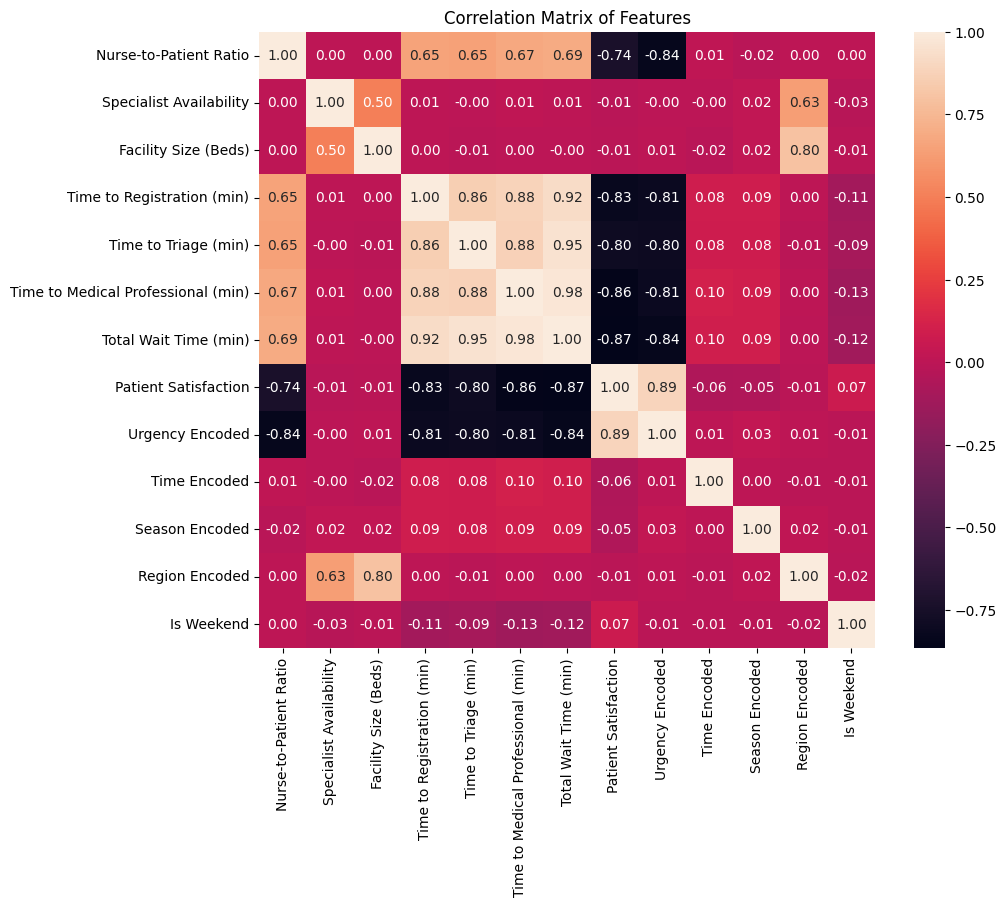

In [92]:
correlation_matrix = df.corr(numeric_only = True)
correlation_matrix

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,cbar=True,annot=True,
                 square=True,fmt='.2f',
                 annot_kws={'size': 10})
plt.title('Correlation Matrix of Features')
plt.show() 

In [93]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

df = df.drop(columns=['Visit ID', 'Patient ID', 'Hospital ID'], errors='ignore')


df = df.dropna(subset=['Total Wait Time (min)'])

X = df.drop(columns=['Total Wait Time (min)'])
y = df['Total Wait Time (min)']

X = pd.get_dummies(X, drop_first=True)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print("Feature importances:\n")
print(importances)

top_features = importances.head(10).index.tolist()
print("\nTop 10 features:", top_features)

Feature importances:

Patient Satisfaction                  0.713984
Time to Medical Professional (min)    0.224451
Time to Triage (min)                  0.055593
Time to Registration (min)            0.004665
Facility Size (Beds)                  0.000191
                                        ...   
Visit Date_2024-04-24 10:34:00        0.000000
Visit Date_2024-04-23 08:21:01        0.000000
Visit Date_2024-04-23 07:35:38        0.000000
Visit Date_2024-11-03 20:36:53        0.000000
Visit Date_2024-07-01 12:30:04        0.000000
Length: 5034, dtype: float64

Top 10 features: ['Patient Satisfaction', 'Time to Medical Professional (min)', 'Time to Triage (min)', 'Time to Registration (min)', 'Facility Size (Beds)', 'Specialist Availability', 'Time Encoded', 'Season Encoded', 'Nurse-to-Patient Ratio', 'Hospital Name_Summit Health Center']


In [94]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV

# Drop IDs
df = df.drop(columns=['Visit ID', 'Patient ID', 'Hospital ID'], errors='ignore')

# Drop rows with missing target
df = df.dropna(subset=['Total Wait Time (min)'])

# Features and target
X = df.drop(columns=['Total Wait Time (min)'])
y = df['Total Wait Time (min)'].astype(float)

# Fill numeric NaNs
# X = X.fillna(X.mean())

# One-hot encode strings
X = pd.get_dummies(X, drop_first=True)

# Train/test split — no stratify for regression
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define XGBoost regressor
xgb = XGBRegressor(
    random_state=42,
    objective='reg:squarederror',  # regression objective
    n_estimators=100
)

# Optional: Grid search for hyperparameters
param_grid = {
    'max_depth': [3],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 1]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',  # regression metric
    cv=5,
    n_jobs=-1
)

# Fit model
grid.fit(X_train, y_train)

# Best score and parameters
print("Best score:", grid.best_score_)
print("Best params:", grid.best_params_)

Best score: -6.740813947075499
Best params: {'learning_rate': 0.2, 'max_depth': 3, 'subsample': 0.7}


In [96]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predict
y_val_pred = grid.predict(X_test)

# Regression metrics
mse = mean_squared_error(y_test, y_val_pred)
mae = mean_absolute_error(y_test, y_val_pred)
r2 = r2_score(y_test, y_val_pred)

print("---- XGBoost Regression Performance ----")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")

---- XGBoost Regression Performance ----
MSE: 5.72
MAE: 1.61
R²: 1.00


## Linear Regression Model

In [105]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# -------------------------------
# Preprocessing
# -------------------------------
# Drop ID columns if any
df = df.drop(columns=['Visit ID', 'Patient ID', 'Hospital ID'], errors='ignore')

# Drop rows with missing target
df = df.dropna(subset=['Total Wait Time (min)'])

# Features and target
# Features and target
X = df.drop(columns=['Total Wait Time (min)'])
y = df['Total Wait Time (min)'].astype(float)

# Fill numeric NaNs only
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].mean())

# One-hot encode categorical columns
X = pd.get_dummies(X, drop_first=True)

# Encode categorical/string columns
# X = pd.get_dummies(X, drop_first=True)

# -------------------------------
# Train/test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Train Linear Regression model
# -------------------------------
model = LinearRegression()
model.fit(X_train, y_train)  # ✅ no NaNs now

# -------------------------------
# Evaluate
# -------------------------------
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f} minutes")
print(f"R² Score: {r2:.4f}")

RMSE: 0.00 minutes
R² Score: 1.0000


In [ ]:
Feature coefficients — which factors drive wait time?
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("Feature Coefficients (impact on Total Wait Time):")
print(coef_df.to_string(index=False))

In [30]:
df['Process Sum'] = (
    df['Time to Registration (min)'] +
    df['Time to Triage (min)'] +
    df['Time to Medical Professional (min)']
)

df['Reg %'] = df['Time to Registration (min)'] / df['Total Wait Time (min)']
df['Triage %'] = df['Time to Triage (min)'] / df['Total Wait Time (min)']
df['Doctor %'] = df['Time to Medical Professional (min)'] / df['Total Wait Time (min)']

contributions = df[['Reg %', 'Triage %', 'Doctor %']].mean()

print(contributions)

Reg %       0.137531
Triage %    0.274616
Doctor %    0.587853
dtype: float64
